<a href="https://colab.research.google.com/github/IrfanWazeer/AIML_NETSOLE_NIAI_Tasks/blob/main/03a_LAB_Logistic_Regression_Error_Metrics_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Foundation

## Course 3, Part a: Logistic Regression LAB


## Introduction

We will be using the [Human Activity Recognition with Smartphones](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones) database, which was built from the recordings of study participants who carried a smartphone with an embedded inertial sensor while performing activities of daily living (ADL). The objective is to classify the activities the participants performed into one of the six following categories: walking, walking upstairs, walking downstairs, sitting, standing, and laying.

The following information is provided for each record in the dataset:

- Triaxial acceleration from the accelerometer (total acceleration) and the estimated body acceleration
- Triaxial Angular velocity from the gyroscope
- A 561-feature vector with time and frequency domain variables
- The activity label

More information about the features are available on the website linked above.


In [9]:
!pip install seaborn
!pip install pandas
!pip install numpy
!pip install  matplotlib
!pip install scikit-learn

In [10]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [11]:
import seaborn as sns, pandas as pd, numpy as np

## Question 1

Import the data and do the following:

* Examine the data types--there are many columns, so it might be wise to use value counts.
* Determine if the floating point values need to be scaled.
* Determine the breakdown of each activity.
* Encode the activity label as an integer.


In [12]:
### BEGIN SOLUTION
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/Human_Activity_Recognition_Using_Smartphones_Data.csv", sep=',')

The data columns are all floats except for the activity label.


In [13]:
data.dtypes.value_counts()

,count
float64,561
object,1


In [14]:
data.dtypes.tail()

,0
"angle(tBodyGyroJerkMean,gravityMean)",float64
"angle(X,gravityMean)",float64
"angle(Y,gravityMean)",float64
"angle(Z,gravityMean)",float64
Activity,object


The data are all scaled from -1 (minimum) to 1.0 (maximum).


In [15]:
data.iloc[:, :-1].min().value_counts()

,count
-1.0,561


In [16]:
data.iloc[:, :-1].max().value_counts()

,count
1.0,561


Examine the breakdown of activities; they are relatively balanced.


In [17]:
data.Activity.value_counts()

,count
Activity,
LAYING,1944
STANDING,1906
SITTING,1777
WALKING,1722
WALKING_UPSTAIRS,1544
WALKING_DOWNSTAIRS,1406


Scikit learn classifiers won't accept a sparse matrix for the prediction column. Thus, either `LabelEncoder` needs to be used to convert the activity labels to integers, or if `DictVectorizer` is used, the resulting matrix must be converted to a non-sparse array.  
Use `LabelEncoder` to fit_transform the "Activity" column, and look at 5 random values.


In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Activity'] = le.fit_transform(data.Activity)
data['Activity'].sample(5)
### END SOLUTION

,Activity
9222,2
6048,5
8422,2
8382,4
5121,1


In [19]:
# Re-load data, encode Activity, and split data to ensure X_train and y_train are defined
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit

# Reload data (from cell 80572ef4-180e-465c-b5a8-9a8d513fe276)
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/Human_Activity_Recognition_Using_Smartphones_Data.csv", sep=',')

# Re-encode 'Activity' column (from cell b141d836-9798-4cb0-9b7c-bc298b094dd4)
le = LabelEncoder()
data['Activity'] = le.fit_transform(data.Activity)

# Define feature_cols (from cell F-jwSURwJEYN)
feature_cols = data.columns[:-1]

# Re-split the data (from cell 72503e40-f74e-43d0-99f7-da9cc2f3e2c3)
strat_shuf_split = StratifiedShuffleSplit(n_splits=1,
                                          test_size=0.3,
                                          random_state=42)

train_idx, test_idx = next(strat_shuf_split.split(data[feature_cols], data.Activity))

X_train = data.loc[train_idx, feature_cols]
y_train = data.loc[train_idx, 'Activity']

X_test  = data.loc[test_idx, feature_cols]
y_test  = data.loc[test_idx, 'Activity']

print("Data, feature_cols, X_train, y_train, X_test, y_test are now defined.")

Data, feature_cols, X_train, y_train, X_test, y_test are now defined.


## Question 2

* Calculate the correlations between the dependent variables.
* Create a histogram of the correlation values.
* Identify those that are most correlated (either positively or negatively).


In [20]:
### BEGIN SOLUTION
# Calculate the correlation values
feature_cols = data.columns[:-1]
corr_values = data[feature_cols].corr()

# Simplify by emptying all the data below the diagonal
tril_index = np.tril_indices_from(corr_values)

# Make the unused values NaNs
for coord in zip(*tril_index):
    corr_values.iloc[coord[0], coord[1]] = np.nan # Corrected from np.NaN to np.nan

# Stack the data and convert to a data frame
corr_values = (corr_values
               .stack()
               .to_frame()
               .reset_index()
               .rename(columns={'level_0':'feature1',
                                'level_1':'feature2',
                                0:'correlation'}))

# Get the absolute values for sorting
corr_values['abs_correlation'] = corr_values.correlation.abs()
### END SOLUTION

A histogram of the absolute value correlations.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

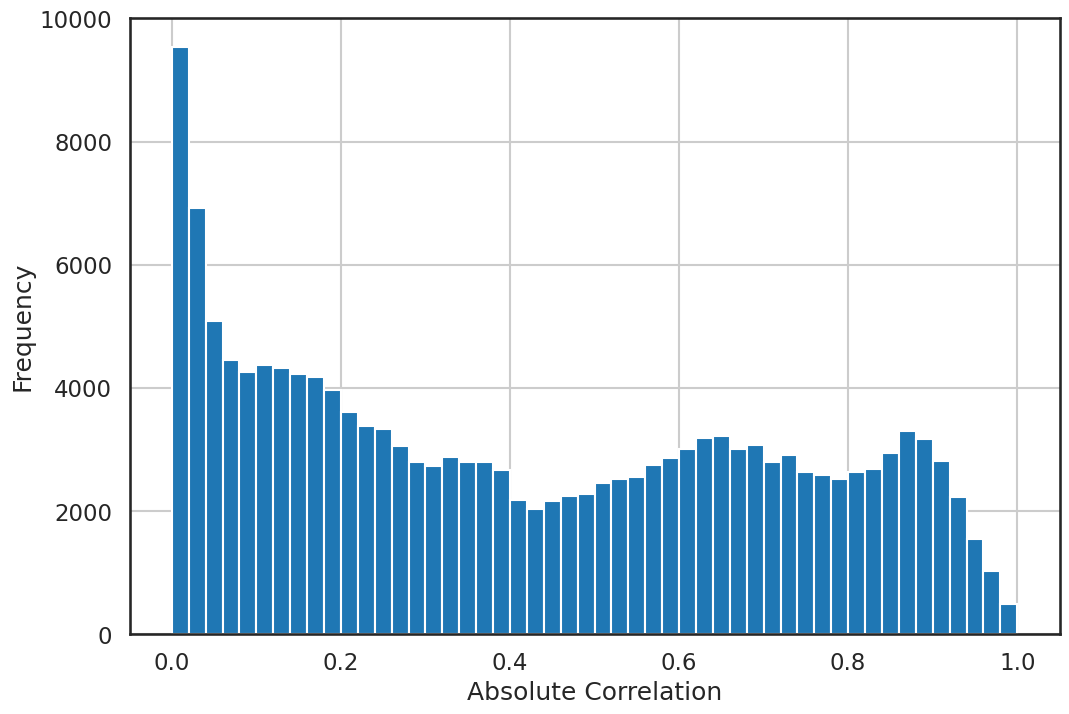

In [22]:
sns.set_context('talk')
sns.set_style('white')

ax = corr_values.abs_correlation.hist(bins=50, figsize=(12, 8))
ax.set(xlabel='Absolute Correlation', ylabel='Frequency');

In [23]:
# The most highly correlated values
corr_values.sort_values('correlation', ascending=False).query('abs_correlation>0.8')
### END SOLUTION

,feature1,feature2,correlation,abs_correlation
93546,tBodyAccMag-min(),tGravityAccMag-min(),1.000000,1.000000
93897,tBodyAccMag-sma(),tGravityAccMag-mean(),1.000000,1.000000
93902,tBodyAccMag-sma(),tGravityAccMag-sma(),1.000000,1.000000
92831,tBodyAccMag-mad(),tGravityAccMag-mad(),1.000000,1.000000
105403,tBodyGyroMag-mean(),tBodyGyroMag-sma(),1.000000,1.000000
...,...,...,...,...
22657,tGravityAcc-mean()-Y,"angle(Y,gravityMean)",-0.993425,0.993425
39225,"tGravityAcc-arCoeff()-Z,3","tGravityAcc-arCoeff()-Z,4",-0.994267,0.994267
38739,"tGravityAcc-arCoeff()-Z,2","tGravityAcc-arCoeff()-Z,3",-0.994628,0.994628
23176,tGravityAcc-mean()-Z,"angle(Z,gravityMean)",-0.994764,0.994764


## Question 3

* Split the data into train and test data sets. This can be done using any method, but consider using Scikit-learn's `StratifiedShuffleSplit` to maintain the same ratio of predictor classes.
* Regardless of the method used to split the data, compare the ratio of classes in both the train and test splits.


In [24]:
### BEGIN SOLUTION
from sklearn.model_selection import StratifiedShuffleSplit

# Get the split indexes
strat_shuf_split = StratifiedShuffleSplit(n_splits=1,
                                          test_size=0.3,
                                          random_state=42)

train_idx, test_idx = next(strat_shuf_split.split(data[feature_cols], data.Activity))

# Create the dataframes
X_train = data.loc[train_idx, feature_cols]
y_train = data.loc[train_idx, 'Activity']

X_test  = data.loc[test_idx, feature_cols]
y_test  = data.loc[test_idx, 'Activity']

In [25]:
y_train.value_counts(normalize=True)

,proportion
Activity,
0,0.188792
2,0.185046
1,0.172562
3,0.167152
5,0.149951
4,0.136496


In [26]:
y_test.value_counts(normalize=True)
### END SOLUTION

,proportion
Activity,
0,0.188673
2,0.185113
1,0.172492
3,0.167314
5,0.149838
4,0.136570


## Question 4

* Fit a logistic regression model without any regularization using all of the features. Be sure to read the documentation about fitting a multi-class model so you understand the coefficient output. Store the model.
* Using cross validation to determine the hyperparameters and fit models using L1 and L2 regularization. Store each of these models as well. Note the limitations on multi-class models, solvers, and regularizations. The regularized models, in particular the L1 model, will probably take a while to fit.


In [27]:
### BEGIN SOLUTION
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

# Standard logistic regression
lr = LogisticRegression(solver='liblinear').fit(X_train, y_train)

In [30]:
from sklearn.linear_model import LogisticRegressionCV

# L1 regularized logistic regression
lr_l1 = LogisticRegressionCV(Cs=10, cv=4, penalty='l1', solver='liblinear').fit(X_train, y_train)

In [28]:
# L2 regularized logistic regression
lr_l2 = LogisticRegressionCV(Cs=10, cv=4, penalty='l2', solver='liblinear').fit(X_train, y_train)
### END SOLUTION

## Question 5

* Compare the magnitudes of the coefficients for each of the models. If one-vs-rest fitting was used, each set of coefficients can be plotted separately.


In [31]:
### BEGIN SOLUTION
# Combine all the coefficients into a dataframe
coefficients = list()

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]

for lab,mod in zip(coeff_labels, coeff_models):
    coeffs = mod.coef_
    coeff_label = pd.MultiIndex(levels=[[lab], [0,1,2,3,4,5]],
                                 codes=[[0,0,0,0,0,0], [0,1,2,3,4,5]])
    coefficients.append(pd.DataFrame(coeffs.T, columns=coeff_label))

coefficients = pd.concat(coefficients, axis=1)

coefficients.sample(10)

lr                                                          l1  \
            0         1         2         3         4         5         0   
152 -0.173063 -0.142732  0.325227  0.174730  0.325345 -0.825248  0.000000   
471  0.001967  0.201009  0.286703  0.114569 -0.008619  0.251072 -0.009153   
464 -0.001755  0.189918  0.225883  0.068558 -0.223170  0.326644 -0.004491   
9   -0.089595 -1.044993 -0.142951 -0.991873  1.142181  1.023176  0.000000   
79  -0.141387  0.019343  0.006189 -0.193711  0.390725 -0.304583  0.000000   
207  0.086239  0.303737 -0.041841 -0.098603  0.069837 -0.896924  0.003967   
235  0.046319 -0.667863  0.722678  0.033682  0.046989 -0.164623  0.000000   
103 -0.041941  0.103499 -0.028093  1.125671 -0.365945  0.846249  0.000000   
203  0.023486 -0.343622 -0.083972 -0.842424  0.421808 -0.105651  0.000000   
462 -0.007573  0.203949  0.163852 -0.076613 -0.465016  0.737650  0.000000   

                                                             l2            \
            1         2         3         4         5         0         1   
152  0.000000  0.000000  0.000000  1.292143 -3.772208 -0.354400  0.387381   
471  0.202666  0.372807  0.000000  0.007942  0.292617 -0.017112  0.408882   
464  0.120762  0.154224  0.000000  0.000000  0.415452 -0.023916  0.406420   
9   -3.800275  0.000000 -0.923987  2.508892  2.749986 -0.133154 -2.948233   
79   0.000000 -0.063044 -0.128061  0.573015 -0.713012  0.118011 -0.021568   
207  0.000000  0.000000  0.000000  0.187282 -2.234597  0.158578  2.232550   
235 -1.742404  1.781925  0.000000  0.005603 -0.257042  0.049039 -1.634866   
103  0.000000 -0.096454  2.182805 -0.151334  0.887624 -0.009788  0.070296   
203  0.000000  0.000000 -0.644094  0.000000 -0.000482  0.064273 -1.590061   
462  0.011608  0.000000  0.000000 -0.285143  0.478355 -0.033430  0.515224   

                                             
            2         3         4         5  
152  0.357401  0.266714  1.520650 -1.828336  
471  0.389420  0.156431  0.095996  0.338490  
464  0.249181  0.348451 -0.564006  0.722154  
9    0.028007 -2.120917  3.030996  2.494664  
79  -0.035418 -0.340517  1.163115 -0.663417  
207 -0.178466  0.001766  0.230775 -1.984546  
235  1.100356  0.145562  0.484631 -0.562080  
103 -0.095342  2.902380 -1.316643  1.061198  
203  0.001445 -2.007324  0.834369 -0.220948  
462  0.215674 -0.218581 -1.349877  1.360392

Prepare six separate plots for each of the multi-class coefficients.


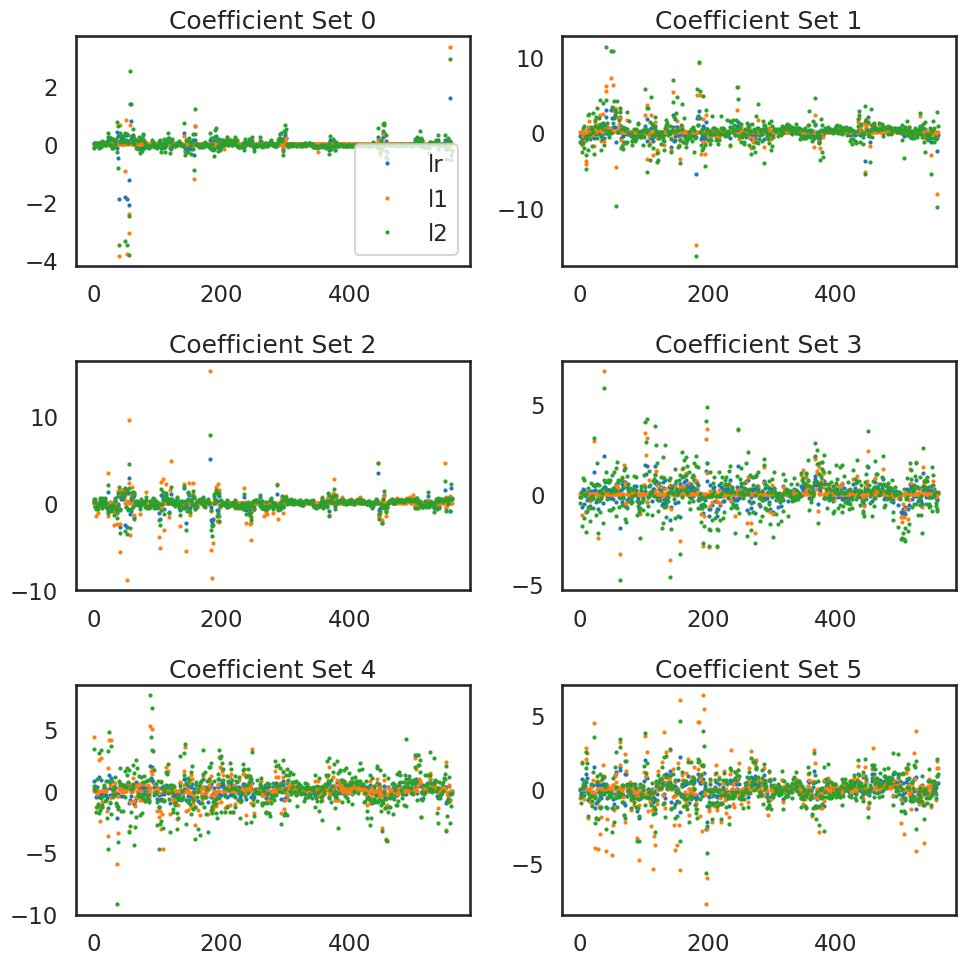

In [32]:
fig, axList = plt.subplots(nrows=3, ncols=2)
axList = axList.flatten()
fig.set_size_inches(10,10)

for ax in enumerate(axList):
    loc = ax[0]
    ax = ax[1]

    data = coefficients.xs(loc, level=1, axis=1)
    data.plot(marker='o', ls='', ms=2.0, ax=ax, legend=False)

    if ax is axList[0]:
        ax.legend(loc=4)

    ax.set(title='Coefficient Set '+str(loc))

plt.tight_layout()
### END SOLUTION

## Question 6

* Predict and store the class for each model.
* Store the probability for the predicted class for each model.


In [33]:
### BEGIN SOLUTION
# Predict the class and the probability for each
y_pred = list()
y_prob = list()

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]

for lab,mod in zip(coeff_labels, coeff_models):
    y_pred.append(pd.Series(mod.predict(X_test), name=lab))
    y_prob.append(pd.Series(mod.predict_proba(X_test).max(axis=1), name=lab))

y_pred = pd.concat(y_pred, axis=1)
y_prob = pd.concat(y_prob, axis=1)

y_pred.head()

,lr,l1,l2
0,3,3,3
1,5,5,5
2,3,3,3
3,1,1,1
4,0,0,0


In [34]:
y_prob.head()
### END SOLUTION

,lr,l1,l2
0,0.998939,0.998926,0.999758
1,0.988165,0.999458,0.999998
2,0.987592,0.995674,0.999902
3,0.981381,0.999170,0.994327
4,0.998277,0.999922,0.999997


## Question 7

For each model, calculate the following error metrics:

* Accuracy
* Precision
* Recall
* F-score
* Confusion Matrix

Decide how to combine the multi-class metrics into a single value for each model.


In [35]:
### BEGIN SOLUTION
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

metrics = list()
cm = dict()

for lab in coeff_labels:

    # Preciision, recall, f-score from the multi-class support function
    precision, recall, fscore, _ = score(y_test, y_pred[lab], average='weighted')

    # The usual way to calculate accuracy
    accuracy = accuracy_score(y_test, y_pred[lab])

    # ROC-AUC scores can be calculated by binarizing the data
    auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2,3,4,5]),
              label_binarize(y_pred[lab], classes=[0,1,2,3,4,5]),
              average='weighted')

    # Last, the confusion matrix
    cm[lab] = confusion_matrix(y_test, y_pred[lab])

    metrics.append(pd.Series({'precision':precision, 'recall':recall,
                              'fscore':fscore, 'accuracy':accuracy,
                              'auc':auc},
                             name=lab))

metrics = pd.concat(metrics, axis=1)

In [36]:
metrics
### END SOLUTION

,lr,l1,l2
precision,0.984144,0.983514,0.984148
recall,0.984142,0.983495,0.984142
fscore,0.984143,0.983492,0.984143
accuracy,0.984142,0.983495,0.984142
auc,0.990384,0.989949,0.990352


## Question 8

* Display or plot the confusion matrix for each model.


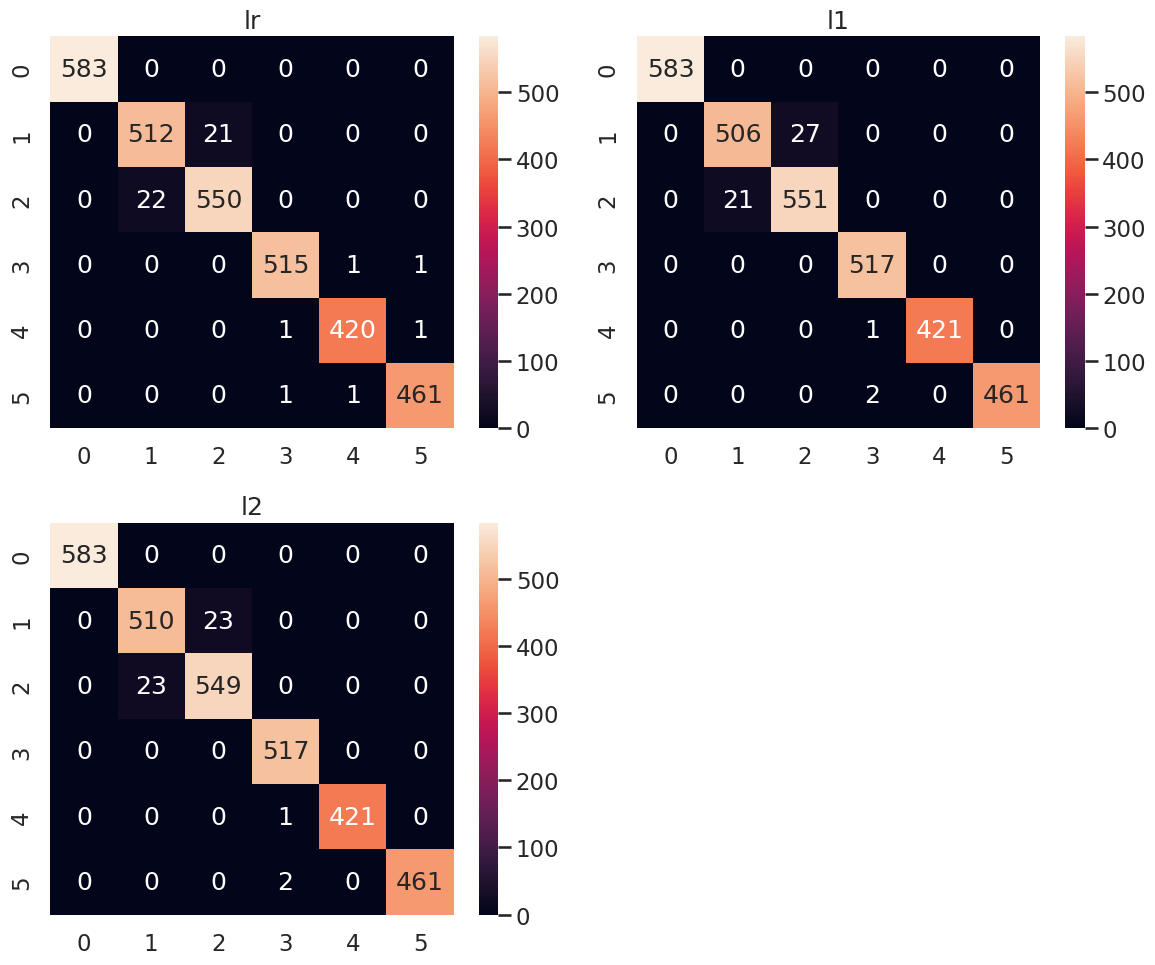

In [37]:
### BEGIN SOLUTION
fig, axList = plt.subplots(nrows=2, ncols=2)
axList = axList.flatten()
fig.set_size_inches(12, 10)

axList[-1].axis('off')

for ax,lab in zip(axList[:-1], coeff_labels):
    sns.heatmap(cm[lab], ax=ax, annot=True, fmt='d');
    ax.set(title=lab);

plt.tight_layout()
### END SOLUTION

---
### Machine Learning Foundation (C) 2020 IBM Corporation
